In [126]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
data = pd.read_csv("spam_and_ham_classification.csv")
print(" Loaded successfully")
print(data.head())
print(data.columns)


✅ Loaded successfully
  label                                               text
0   ham  into the kingdom of god and those that are ent...
1  spam  there was flow at hpl meter 1505 on april firs...
2   ham  take a look at this one campaign for bvyhprice...
3  spam  somu wrote actually thats what i was looking f...
4  spam  fathi boudra wrote i fixed the issue in the sv...
Index(['label', 'text'], dtype='object')


In [ ]:
data.columns = data.columns.str.strip().str.lower()
print(" Columns:", data.columns)


✅ Columns: Index(['label', 'text'], dtype='object')


In [129]:
data = data.dropna(subset=["label", "text"])
print("Before removing duplicates:", len(data))

data = data.drop_duplicates()
print("After removing duplicates:", len(data))


Before removing duplicates: 9989
After removing duplicates: 9989


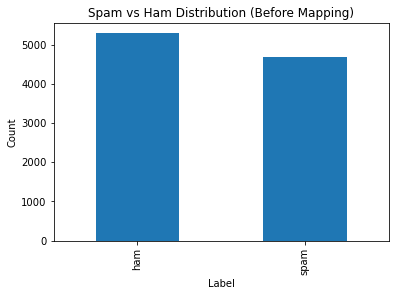

In [130]:
data["label"] = data["label"].astype(str).str.lower().str.strip()

plt.figure(figsize=(6,4))
data["label"].value_counts().plot(kind="bar")
plt.title("Spam vs Ham Distribution (Before Mapping)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


In [ ]:
data["label"] = data["label"].map({"ham": 0, "spam": 1})
data = data.dropna(subset=["label"])
data["label"] = data["label"].astype(int)

print(" Labels converted successfully")
print(data["label"].value_counts())


✅ Labels converted successfully
0    5294
1    4695
Name: label, dtype: int64


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"\d+", " NUMBER ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_text"] = data["text"].apply(clean_text)

print(" Clean text created")
data[["text", "clean_text"]].head()


✅ Clean text created


,text,clean_text
0,into the kingdom of god and those that are ent...,into the kingdom of god and those that are ent...
1,there was flow at hpl meter 1505 on april firs...,there was flow at hpl meter NUMBER on april fi...
2,take a look at this one campaign for bvyhprice...,take a look at this one campaign for bvyhprice...
3,somu wrote actually thats what i was looking f...,somu wrote actually thats what i was looking f...
4,fathi boudra wrote i fixed the issue in the sv...,fathi boudra wrote i fixed the issue in the sv...


In [ ]:
X = data["clean_text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(" Split done")
print("Train size:", len(X_train))
print("Test size:", len(X_test))


✅ Split done
Train size: 7491
Test size: 2498


In [ ]:
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(" TF-IDF done")
print("Train TF-IDF shape:", X_train_tfidf.shape)


✅ TF-IDF done
Train TF-IDF shape: (7491, 119715)


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("\n Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))



✅ Naive Bayes Results
Accuracy: 0.9719775820656525
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1324
           1       0.95      0.99      0.97      1174

    accuracy                           0.97      2498
   macro avg       0.97      0.97      0.97      2498
weighted avg       0.97      0.97      0.97      2498



<Figure size 360x360 with 0 Axes>

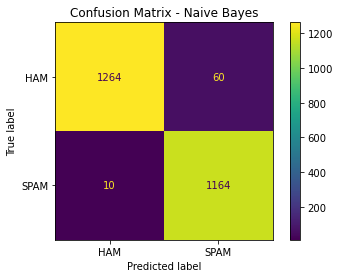

In [136]:
cm_nb = confusion_matrix(y_test, nb_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["HAM", "SPAM"])

plt.figure(figsize=(5,5))
disp_nb.plot(values_format="d")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


In [ ]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("\n SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))



✅ SVM Results
Accuracy: 0.9835868694955965
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1324
           1       0.99      0.98      0.98      1174

    accuracy                           0.98      2498
   macro avg       0.98      0.98      0.98      2498
weighted avg       0.98      0.98      0.98      2498



<Figure size 360x360 with 0 Axes>

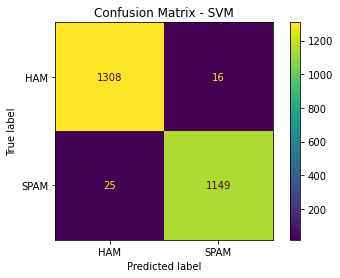

In [138]:
cm_svm = confusion_matrix(y_test, svm_pred)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["HAM", "SPAM"])

plt.figure(figsize=(5,5))
disp_svm.plot(values_format="d")
plt.title("Confusion Matrix - SVM")
plt.show()


In [ ]:
joblib.dump(nb_model, "nb_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print(" Models saved successfully:")
print("nb_model.pkl, svm_model.pkl, tfidf_vectorizer.pkl")



✅ Models saved successfully:
nb_model.pkl, svm_model.pkl, tfidf_vectorizer.pkl


In [140]:
print("SVM classes:", svm_model.classes_)
print("NB classes:", nb_model.classes_)


SVM classes: [0 1]
NB classes: [0 1]
